In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_price_plots(FILENAME: str, day: int) -> None:
    df = pd.read_csv(FILENAME, delimiter=';')
    root = df[df['product'] == 'INTARIAN_PEPPER_ROOT']
    osmium = df[df['product'] == 'ASH_COATED_OSMIUM']
    
    price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
    for col in price_cols:
        osmium[col] = osmium[col].replace(0, pd.NA)
        root[col] = root[col].replace(0, pd.NA)
    
    osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()
    root[price_cols] = root[root.columns.intersection(price_cols)].ffill()

    fig, ax = plt.subplots(figsize=(8, 5))
    plt.title(f'Day {day} Root Prices')
    ax.grid()
    ax.plot(root['timestamp'], root['bid_price_1'], color='red', label='Root Bid Price 1', alpha=0.5)

    ax.plot(root['timestamp'], root['ask_price_1'], color='green', label='Root Ask Price 1', alpha=0.5)

    ax.plot(root['timestamp'], root['mid_price'], linestyle='dashed', color='grey', label='Root Mid Price')
    plt.legend(loc='lower right')

    fig, ax = plt.subplots(figsize=(8, 5))
    plt.title(f'Day {day} Osmium Prices')
    ax.grid()
    ax.plot(osmium['timestamp'], osmium['bid_price_1'], color='red', label='Osmium Bid Price 1', alpha=0.5)

    ax.plot(osmium['timestamp'], osmium['ask_price_1'], color='green', label='Osmium Ask Price 1', alpha=0.5)

    ax.plot(osmium['timestamp'], osmium['mid_price'], linestyle='dashed', color='grey', label='Osmium Mid Price')
    plt.legend(loc='lower right')

C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\4243613686.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osmium[col] = osmium[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\4243613686.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  root[col] = root[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\4243613686.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call resu

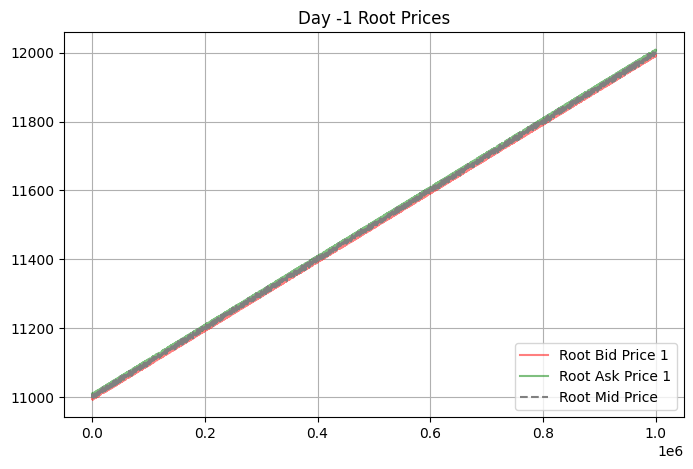

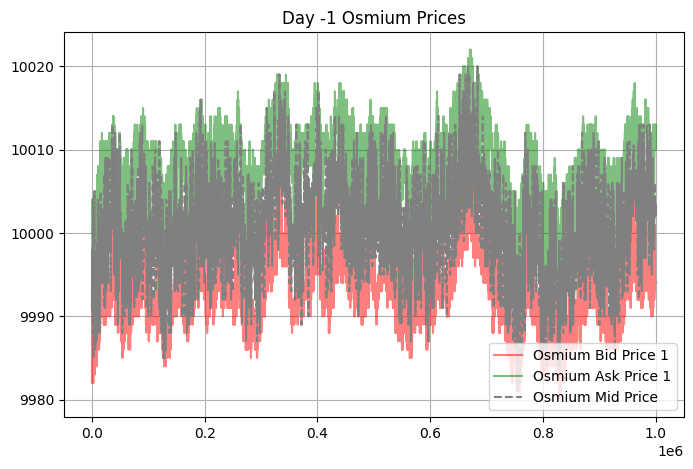

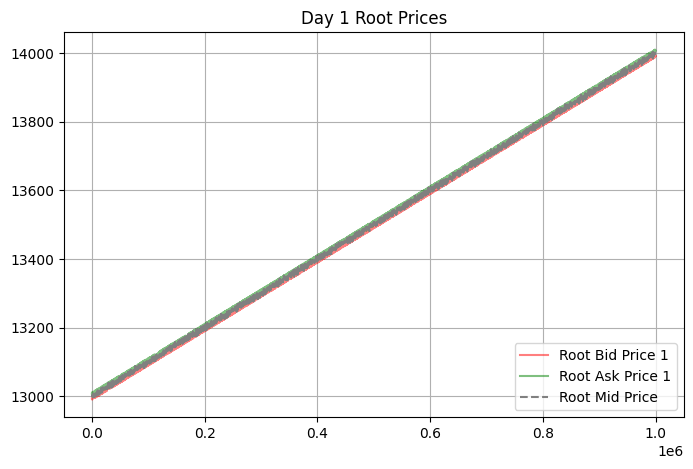

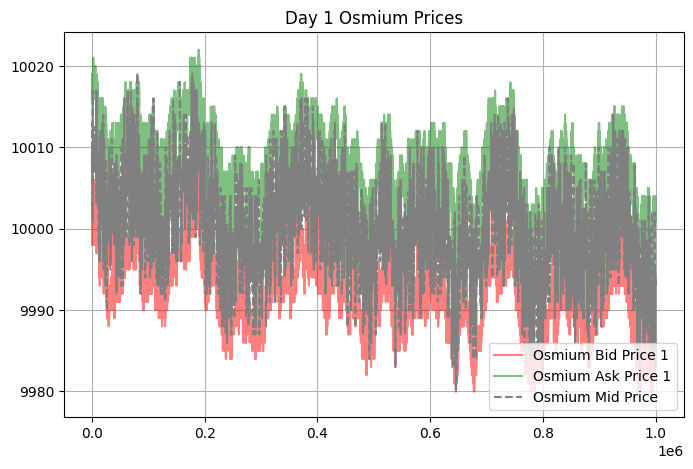

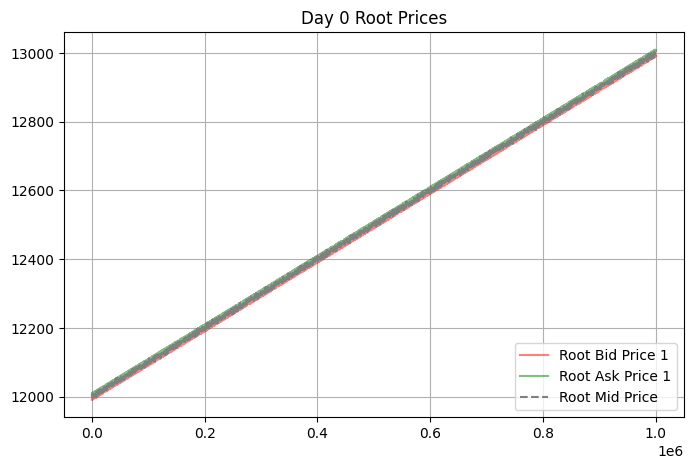

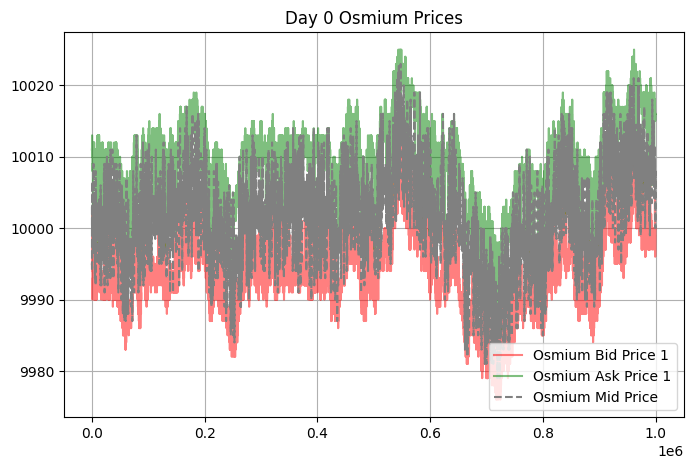

In [6]:
files = {-1: '../Round 2/Data/prices_round_2_day_-1.csv', 
         1: '../Round 2/Data/prices_round_2_day_1.csv', 
         0: '../Round 2/Data/prices_round_2_day_0.csv'}

for key, val in files.items():
    get_price_plots(FILENAME=val, day=key)

C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\3277843650.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()


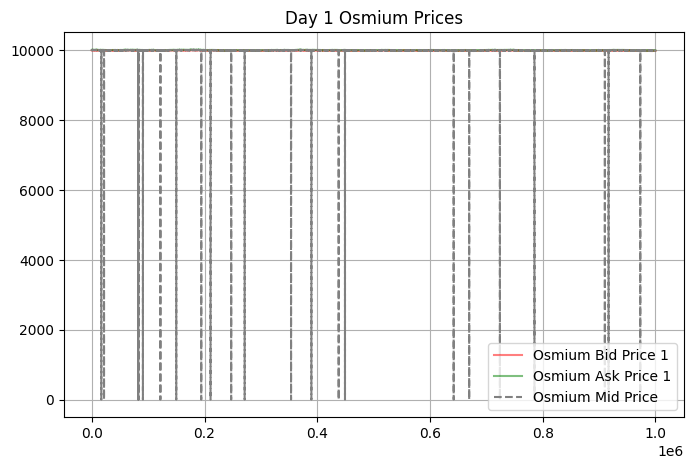

In [7]:
df = pd.read_csv('../Round 2/Data/prices_round_2_day_1.csv', delimiter=';')
osmium = df[df['product'] == 'ASH_COATED_OSMIUM']

price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
# for col in price_cols:
#     osmium[col] = osmium[col].replace(0, pd.NA)

osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()

fig, ax = plt.subplots(figsize=(8, 5))
plt.title('Day 1 Osmium Prices')
ax.grid()
ax.plot(osmium['timestamp'], osmium['bid_price_1'], color='red', label='Osmium Bid Price 1', alpha=0.5)

ax.plot(osmium['timestamp'], osmium['ask_price_1'], color='green', label='Osmium Ask Price 1', alpha=0.5)

ax.plot(osmium['timestamp'], osmium['mid_price'], linestyle='dashed', color='grey', label='Osmium Mid Price')
plt.legend(loc='lower right')

C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\1771031169.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roots[price_cols] = roots[roots.columns.intersection(price_cols)].ffill()


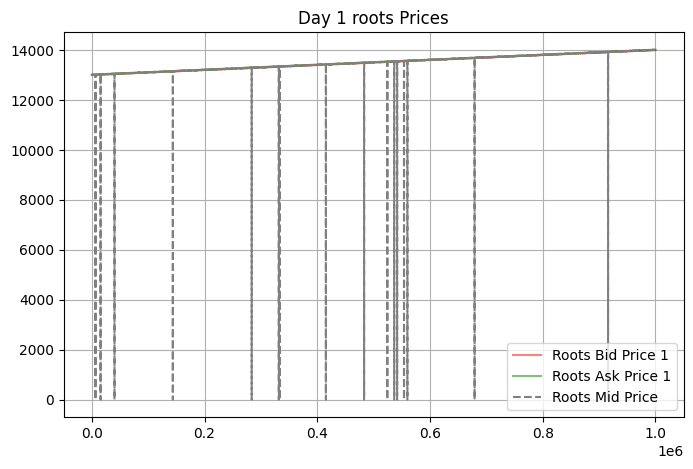

In [8]:
df = pd.read_csv('../Round 2/Data/prices_round_2_day_1.csv', delimiter=';')
roots = df[df['product'] == 'INTARIAN_PEPPER_ROOT']

price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
# for col in price_cols:
#     roots[col] = roots[col].replace(0, pd.NA)

roots[price_cols] = roots[roots.columns.intersection(price_cols)].ffill()

fig, ax = plt.subplots(figsize=(8, 5))
plt.title('Day 1 roots Prices')
ax.grid()
ax.plot(roots['timestamp'], roots['bid_price_1'], color='red', label='Roots Bid Price 1', alpha=0.5)

ax.plot(roots['timestamp'], roots['ask_price_1'], color='green', label='Roots Ask Price 1', alpha=0.5)

ax.plot(roots['timestamp'], roots['mid_price'], linestyle='dashed', color='grey', label='Roots Mid Price')
plt.legend(loc='lower right')

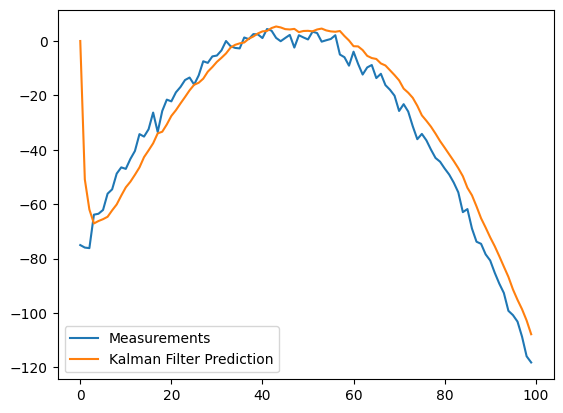

In [23]:
import numpy as np

class KalmanFilter(object):
    def __init__(self, F = None, Z = None, Q = None, eps = None, P = None, x0 = None):

        if(F is None or Z is None):
            raise ValueError("Set proper system dynamics.")

        self.n = F.shape[1]
        self.m = Z.shape[1]

        # The transition matrix, set F = 1 - like a random walk
        self.F = F

        # Observation model, set Z = 1
        self.Z = Z

        # Process noise - Hidden Pattern
        self.Q = np.eye(self.n) if Q is None else Q

        # Measurement noise
        self.eps = np.eye(self.n) if eps is None else eps

        # Error covariance
        self.P = np.eye(self.n) if P is None else P

        # state estimate
        self.x = np.zeros((self.n, 1)) if x0 is None else x0

    def predict(self, u = 0):
        self.x = np.dot(self.F, self.x) 
        self.P = np.dot(np.dot(self.F, self.P), self.F.T) + self.Q
        return self.x

    def update(self, z):
        y = z - np.dot(self.Z, self.x)
        S = self.eps + np.dot(self.Z, np.dot(self.P, self.Z.T))
        K = np.dot(np.dot(self.P, self.Z.T), np.linalg.inv(S))
        self.x = self.x + np.dot(K, y)
        I = np.eye(self.n)
        self.P = np.dot(np.dot(I - np.dot(K, self.Z), self.P), 
        	(I - np.dot(K, self.Z)).T) + np.dot(np.dot(K, self.eps), K.T)

def example():
	dt = 1.0/60
	F = np.array([[1, dt, 0], [0, 1, dt], [0, 0, 1]])
	Z = np.array([1, 0, 0]).reshape(1, 3)
	Q = np.array([[0.05, 0.05, 0.0], [0.05, 0.05, 0.0], [0.0, 0.0, 0.0]])
	eps = np.array([0.5]).reshape(1, 1)

	x = np.linspace(-10, 10, 100)
	measurements = - (x**2 + 2*x - 2)  + np.random.normal(0, 2, 100)

	kf = KalmanFilter(F = F, Z = Z, Q = Q, eps = eps)
	predictions = []

	for z in measurements:
		predictions.append(np.dot(Z,  kf.predict())[0])
		kf.update(z)

	import matplotlib.pyplot as plt
	plt.plot(range(len(measurements)), measurements, label = 'Measurements')
	plt.plot(range(len(predictions)), np.array(predictions), label = 'Kalman Filter Prediction')
	plt.legend()
	plt.show()

if __name__ == '__main__':
    example()

In [53]:
df = pd.read_csv('../Round 2/Data/prices_round_2_day_1.csv', delimiter=';')
osmium_1 = df[df['product'] == 'ASH_COATED_OSMIUM']

price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
for col in price_cols:
    osmium_1[col] = osmium_1[col].replace(0, pd.NA)

osmium_1[price_cols] = osmium_1[osmium_1.columns.intersection(price_cols)].ffill()

C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\298386642.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osmium_1[col] = osmium_1[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\298386642.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  osmium_1[price_cols] = osmium_1[osmium_1.columns.intersection(price_cols)].ffill()
C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\298386642.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [54]:
display(osmium_1)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
1,1,0,ASH_COATED_OSMIUM,10000.0,13.0,9998.0,21.0,NaN,NaN,10016.0,13.0,10019.0,21.0,NaN,NaN,10008.0,0.0
3,1,100,ASH_COATED_OSMIUM,10000.0,15.0,9998.0,26.0,NaN,NaN,10019.0,26.0,NaN,NaN,NaN,NaN,10009.5,0.0
4,1,200,ASH_COATED_OSMIUM,10000.0,15.0,9998.0,30.0,NaN,NaN,10019.0,30.0,NaN,NaN,NaN,NaN,10009.5,0.0
7,1,300,ASH_COATED_OSMIUM,9998.0,27.0,NaN,NaN,NaN,NaN,10016.0,12.0,10019.0,27.0,NaN,NaN,10007.0,0.0
9,1,400,ASH_COATED_OSMIUM,10010.0,8.0,10000.0,12.0,9998.0,25.0,10016.0,12.0,10019.0,25.0,NaN,NaN,10013.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19990,1,999500,ASH_COATED_OSMIUM,9986.0,11.0,9983.0,28.0,NaN,NaN,10002.0,11.0,10004.0,28.0,NaN,NaN,9994.0,0.0
19993,1,999600,ASH_COATED_OSMIUM,9986.0,13.0,9983.0,30.0,NaN,NaN,10002.0,13.0,10004.0,30.0,NaN,NaN,9994.0,0.0
19995,1,999700,ASH_COATED_OSMIUM,9985.0,13.0,9983.0,28.0,NaN,NaN,10001.0,13.0,10004.0,28.0,NaN,NaN,9993.0,0.0
19997,1,999800,ASH_COATED_OSMIUM,9985.0,10.0,9982.0,27.0,NaN,NaN,10001.0,10.0,10003.0,27.0,NaN,NaN,9993.0,0.0


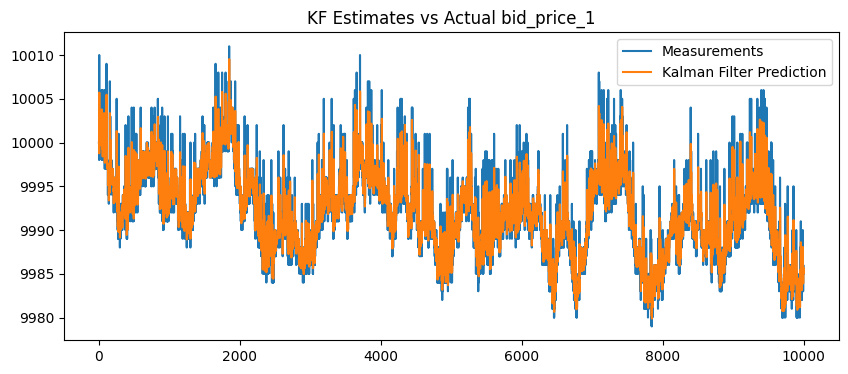

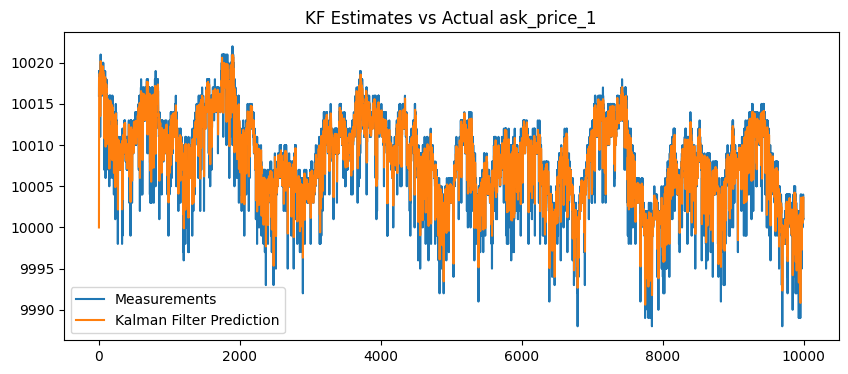

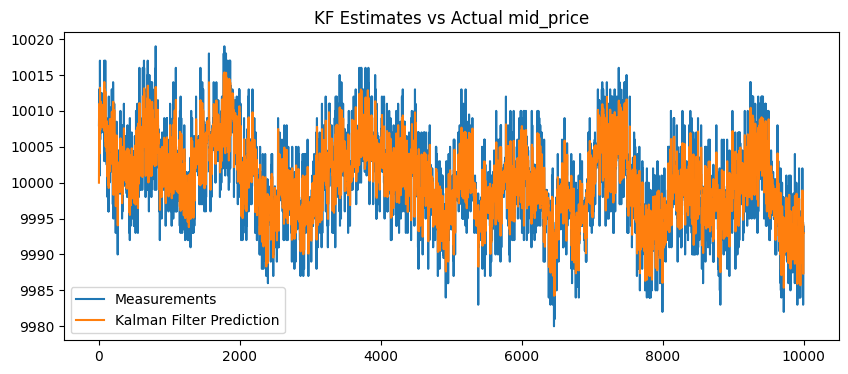

In [55]:
# set transition matrix, n = 1 since there is only state, the true price, to track
n = 1
F = np.identity(n)

# set observation matrix to scalar 1 since the state is the "true" price
Z = np.identity(n)

# Q needs to be tuned

# set x0 to be 10000 since the osmium hovers around that level
x0 = 10000

for col in price_cols:
    measurements = np.array(osmium_1[col])
    kf = KalmanFilter(F = F, Z = Z, x0 = x0)

    predictions = []
    for z in measurements:
        predictions.append(np.dot(Z,  kf.predict())[0])
        kf.update(z)
    fig, ax = plt.subplots(figsize=(10, 4))
    plt.plot(range(len(measurements)), measurements, label = 'Measurements')
    plt.plot(range(len(predictions)), np.array(predictions), label = 'Kalman Filter Prediction')
    plt.title(f'KF Estimates vs Actual {col}')
    plt.legend()
    plt.show()
